## Setup and Imports

In [3]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patches
import torch
import json
from collections import defaultdict
from PIL import Image

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

# Set paths
project_root = Path.cwd()
data_root = project_root / 'data'
test_seq = 'SNMOT-122'
seq_path = data_root / 'tracking-2023' / 'test' / test_seq
img_dir = seq_path / 'img1'
gt_file = seq_path / 'gt' / 'gt.txt'

print(f"\nUsing sequence: {test_seq}")
print(f"Images: {img_dir}")
print(f"Ground truth: {gt_file}")

PyTorch version: 2.7.1
CUDA available: False

Using sequence: SNMOT-122
Images: /Users/yashpatel/Documents/Bocconi/Classes/Year 2/Semester 1/Deep Learning for Computer Vision/Project/Code/data/tracking-2023/test/SNMOT-122/img1
Ground truth: /Users/yashpatel/Documents/Bocconi/Classes/Year 2/Semester 1/Deep Learning for Computer Vision/Project/Code/data/tracking-2023/test/SNMOT-122/gt/gt.txt


## Load Ground Truth Annotations

In [4]:
# Load ground truth and ball track IDs
ball_tracks_file = data_root / 'ball_tracks.json'
with open(ball_tracks_file, 'r') as f:
    ball_tracks = json.load(f)

ball_track_ids = set(ball_tracks.get(test_seq, []))
print(f"Ball track IDs for {test_seq}: {ball_track_ids}")

# Parse ground truth file
gt_per_frame = defaultdict(list)
with open(gt_file, 'r') as f:
    for line in f:
        if not line.strip():
            continue
        parts = line.strip().split(',')
        frame_id = int(float(parts[0]))
        track_id = int(float(parts[1]))
        x, y, w, h = float(parts[2]), float(parts[3]), float(parts[4]), float(parts[5])
        
        # Determine class: 1 if ball, 0 if player
        class_id = 1 if track_id in ball_track_ids else 0
        
        gt_per_frame[frame_id].append({
            'bbox': [x, y, w, h],
            'class': class_id,
            'track_id': track_id
        })

print(f"\nLoaded ground truth for {len(gt_per_frame)} frames")
print(f"Sample frame {list(gt_per_frame.keys())[0]}: {len(gt_per_frame[list(gt_per_frame.keys())[0]])} objects")

Ball track IDs for SNMOT-122: {20}

Loaded ground truth for 750 frames
Sample frame 1: 19 objects


## Load YOLOv8 Model

In [5]:
from ultralytics import YOLO

# Load YOLOv8 checkpoint
yolo_checkpoint = project_root / 'tracking_baseline' / 'train' / 'runs' / 'yolo' / 'azure_full_v12' / 'weights' / 'best.pt'

if yolo_checkpoint.exists():
    yolo_model = YOLO(str(yolo_checkpoint))
    print(f"✓ Loaded YOLOv8 model from {yolo_checkpoint.name}")
    yolo_available = True
else:
    print(f"✗ YOLOv8 checkpoint not found at {yolo_checkpoint}")
    print("  Model should be available from GitHub")
    yolo_available = False

✓ Loaded YOLOv8 model from best.pt


## Helper Functions for Visualization

In [6]:
def draw_boxes(img, detections, title="", show_conf=False):
    """
    Draw bounding boxes on image.
    
    Args:
        img: numpy array (H, W, 3) in RGB
        detections: list of dicts with 'bbox' (x,y,w,h), 'class' (0=player, 1=ball), optional 'score'
        title: title for the subplot
        show_conf: whether to show confidence scores
    """
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    ax.imshow(img)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')
    
    for det in detections:
        x, y, w, h = det['bbox']
        class_id = det['class']
        
        # Color: blue for players, red for ball
        color = 'red' if class_id == 1 else 'blue'
        
        # Draw rectangle
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        
        # Add confidence score if available
        if show_conf and 'score' in det:
            score_text = f"{det['score']:.2f}"
            ax.text(x, y - 5, score_text, color=color, fontsize=8, 
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
    
    return fig, ax


def draw_comparison(img, gt_dets, yolo_dets, frame_id):
    """
    Draw side-by-side comparison of Ground Truth and YOLOv8.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Ground Truth
    axes[0].imshow(img)
    axes[0].set_title('Ground Truth', fontsize=12, fontweight='bold')
    axes[0].axis('off')
    for det in gt_dets:
        x, y, w, h = det['bbox']
        color = 'red' if det['class'] == 1 else 'blue'
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor=color, facecolor='none')
        axes[0].add_patch(rect)
    
    # YOLOv8
    axes[1].imshow(img)
    axes[1].set_title('YOLOv8', fontsize=12, fontweight='bold')
    axes[1].axis('off')
    for det in yolo_dets:
        x, y, w, h = det['bbox']
        color = 'red' if det['class'] == 1 else 'blue'
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor=color, facecolor='none')
        axes[1].add_patch(rect)
        if 'score' in det:
            axes[1].text(x, y - 5, f"{det['score']:.2f}", color=color, fontsize=8,
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
    
    plt.suptitle(f'Frame {frame_id}', fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()
    return fig


def predict_yolo(model, img_path, conf_thresh=0.25):
    """
    Run YOLO inference on an image path.
    Returns list of detections with bbox, class, score.
    """
    results = model.predict(str(img_path), conf=conf_thresh, imgsz=832, verbose=False)
    
    detections = []
    for result in results:
        boxes = result.boxes
        if boxes is None:
            continue
            
        for box in boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            conf = box.conf[0].cpu().item()
            cls = int(box.cls[0].cpu().item())
            
            detections.append({
                'bbox': [float(x1), float(y1), float(x2-x1), float(y2-y1)],
                'class': cls,  # Already 0=player, 1=ball
                'score': float(conf)
            })
    
    return detections

print("✓ Helper functions defined")

✓ Helper functions defined


## Generate Comparison Visualizations

We'll visualize a selection of frames showing side-by-side comparison of:
- Ground truth annotations
- YOLOv8 predictions

**Color coding:**
- 🔵 Blue boxes = Players (class 0)
- 🔴 Red boxes = Ball (class 1)

Visualizing 10 frames: [1, 51, 101, 151, 201, 251, 301, 351, 401, 451]

Generating predictions and visualizations...
This may take a few minutes depending on hardware.



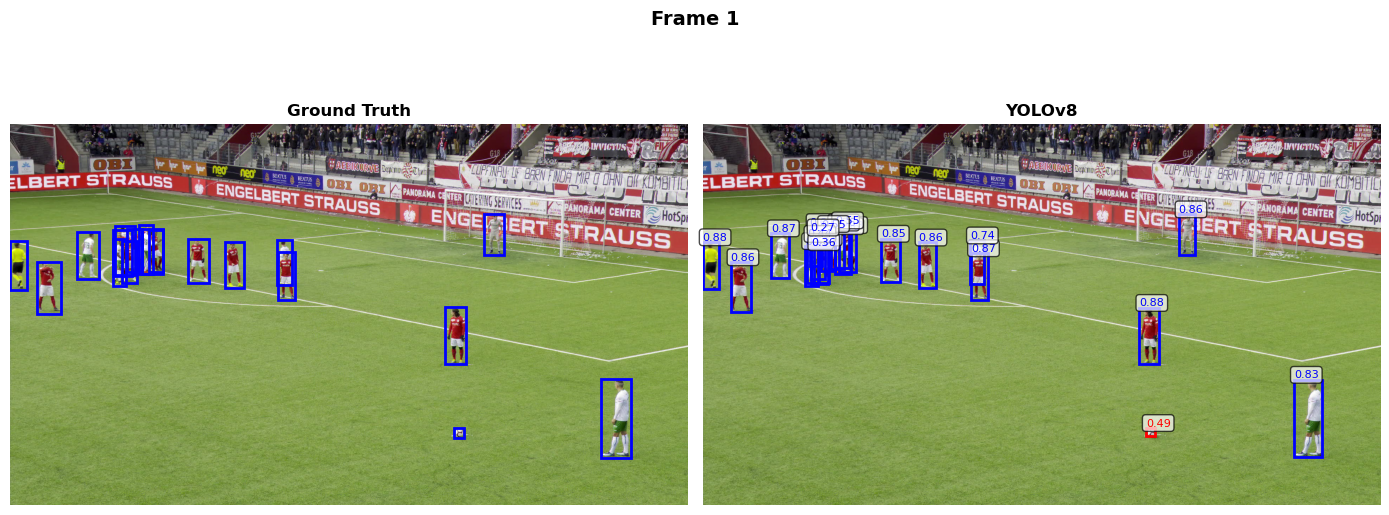

Frame 1:
  GT: 19 objects (19 players, 0 balls)
  YOLO: 22 detections (21 players, 1 balls)



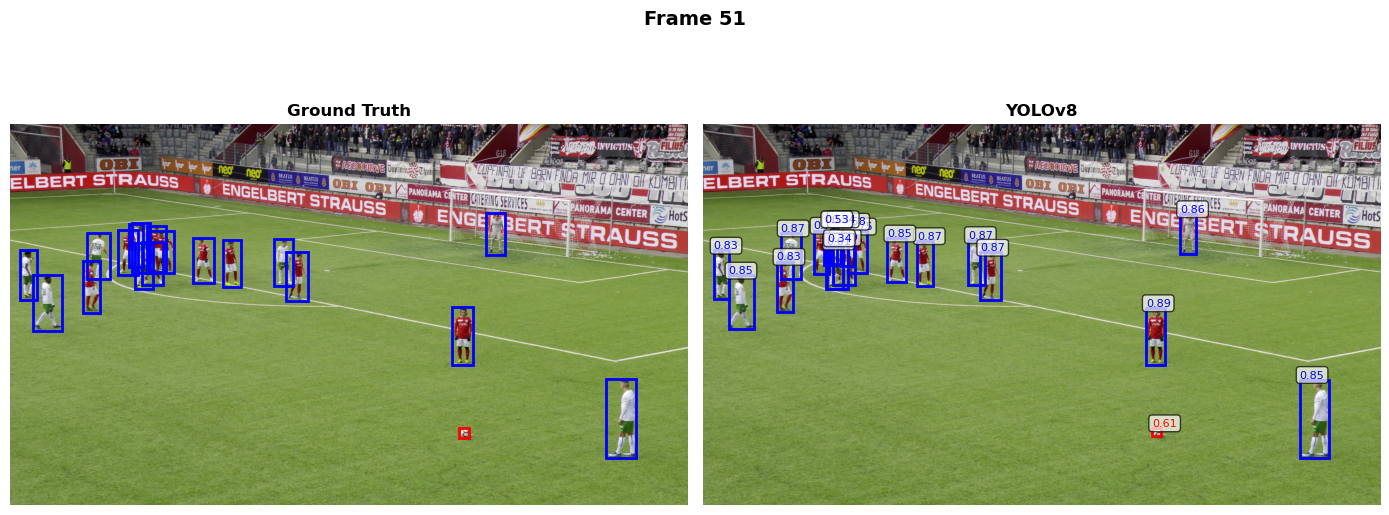

Frame 51:
  GT: 19 objects (18 players, 1 balls)
  YOLO: 21 detections (20 players, 1 balls)



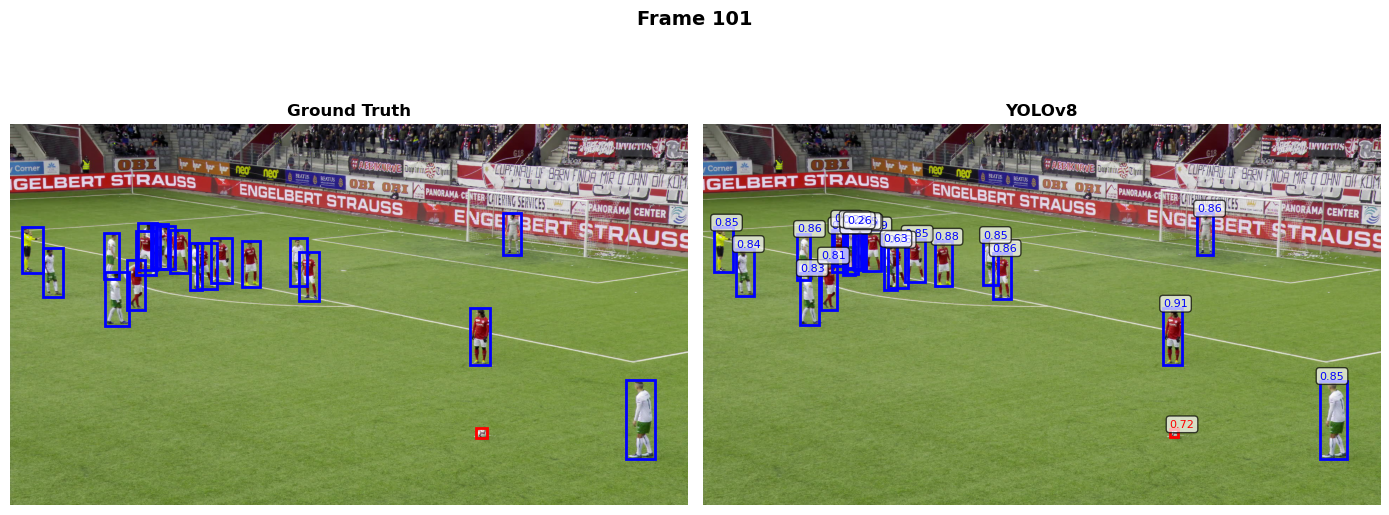

Frame 101:
  GT: 21 objects (20 players, 1 balls)
  YOLO: 24 detections (23 players, 1 balls)



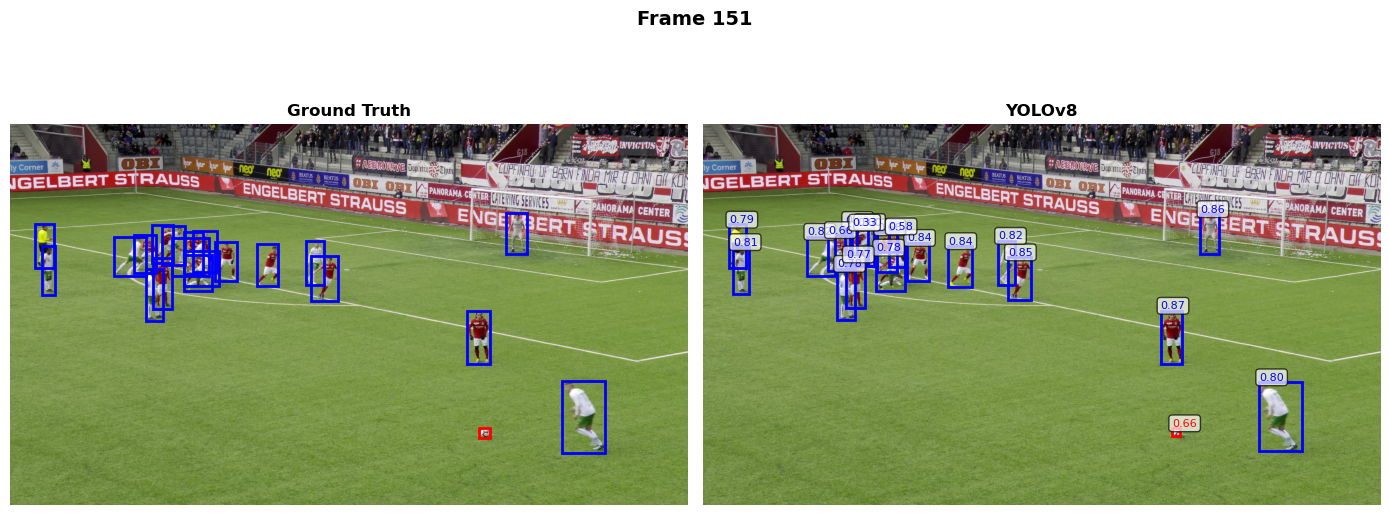

Frame 151:
  GT: 21 objects (20 players, 1 balls)
  YOLO: 20 detections (19 players, 1 balls)



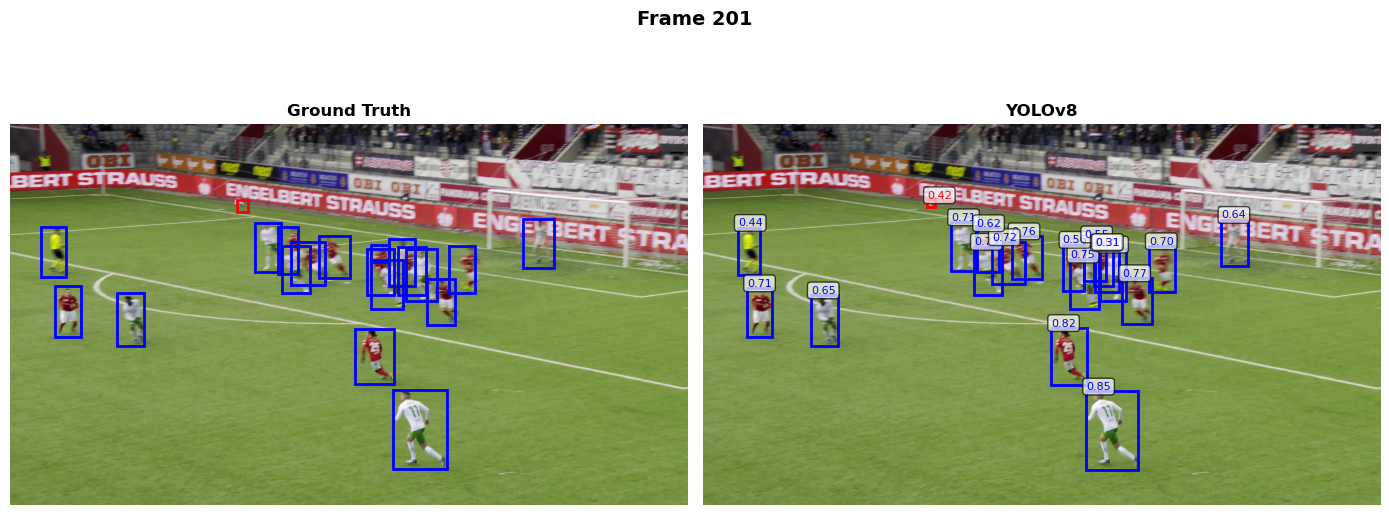

Frame 201:
  GT: 20 objects (19 players, 1 balls)
  YOLO: 20 detections (19 players, 1 balls)



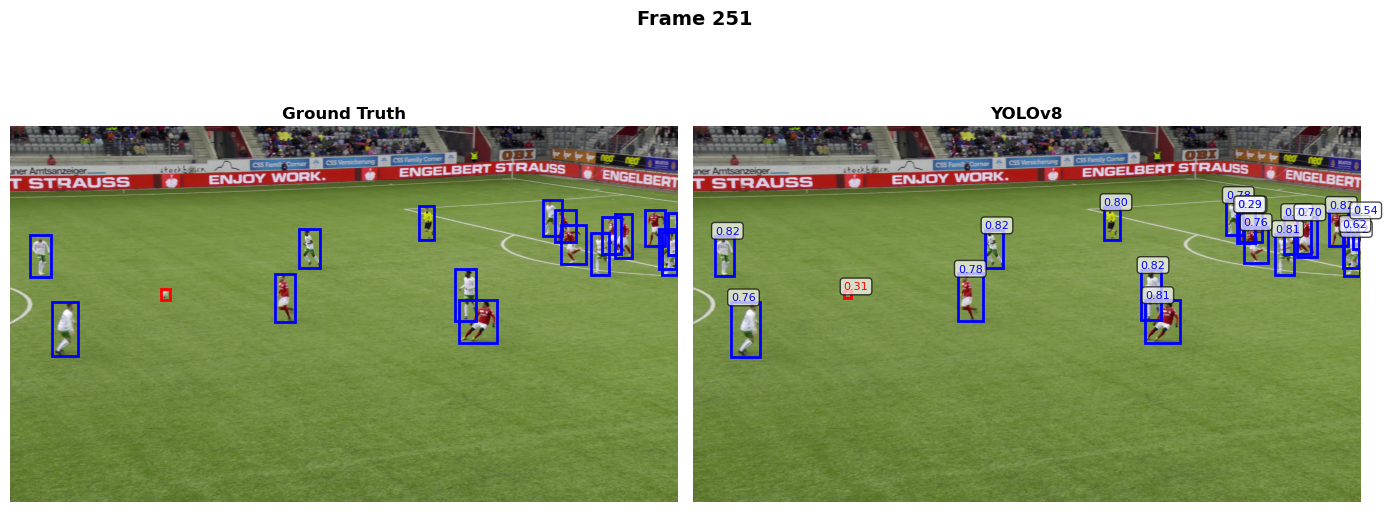

Frame 251:
  GT: 18 objects (17 players, 1 balls)
  YOLO: 19 detections (18 players, 1 balls)



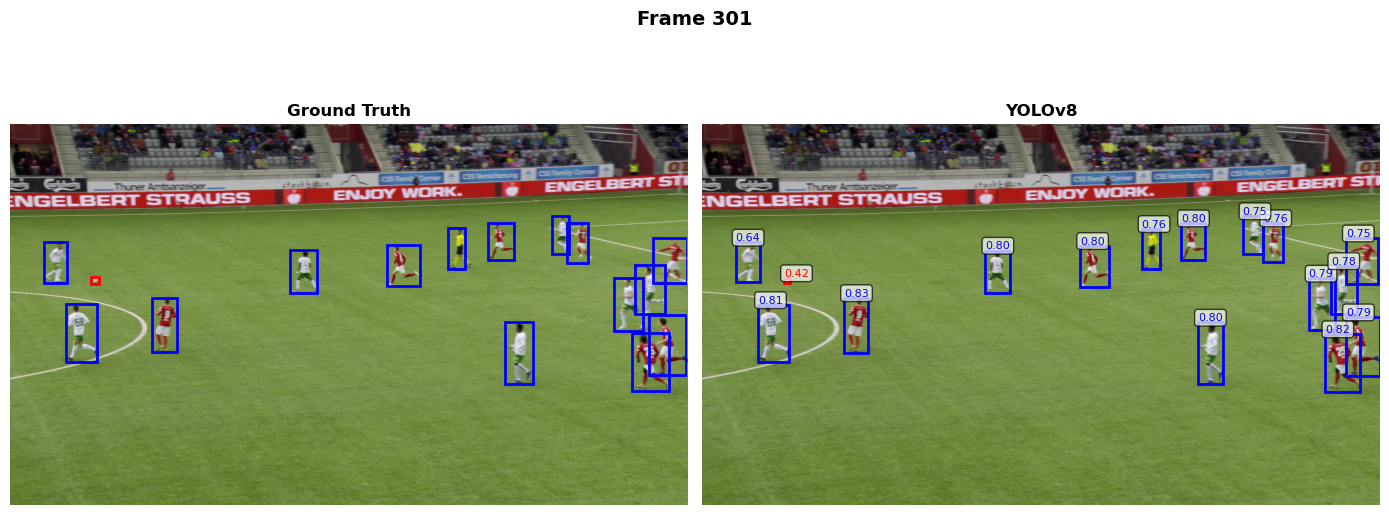

Frame 301:
  GT: 16 objects (15 players, 1 balls)
  YOLO: 16 detections (15 players, 1 balls)



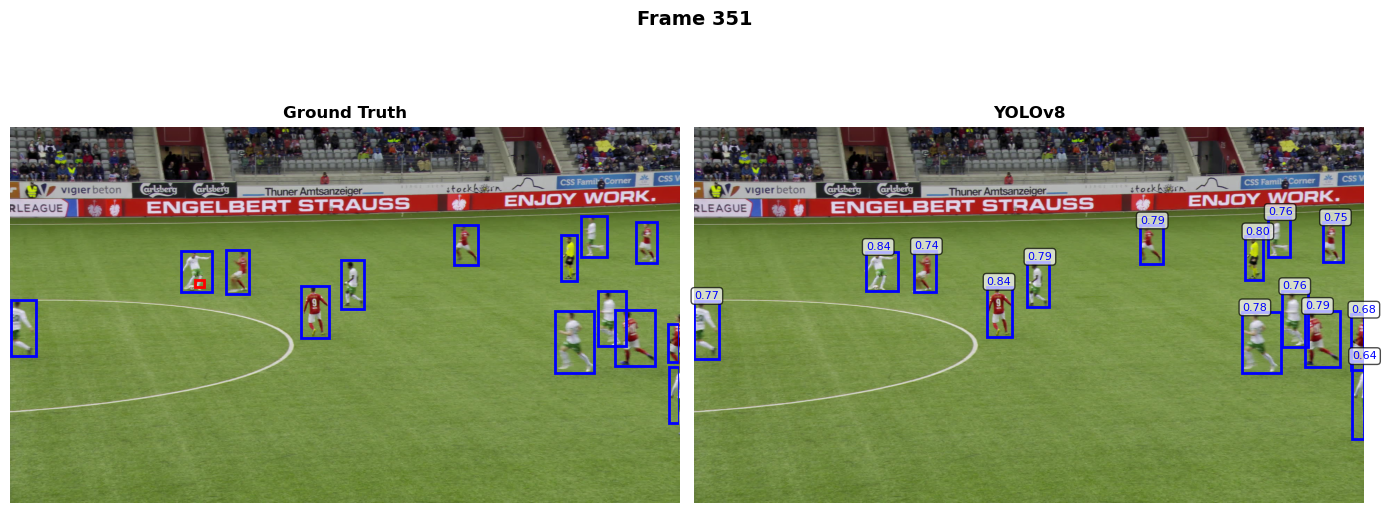

Frame 351:
  GT: 15 objects (14 players, 1 balls)
  YOLO: 14 detections (14 players, 0 balls)



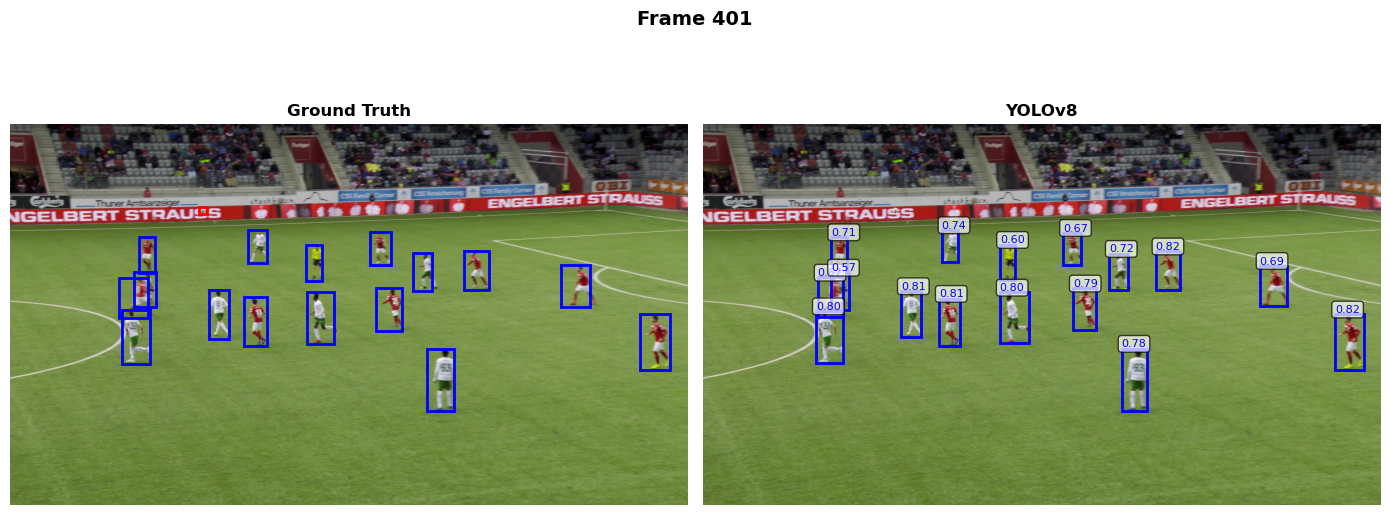

Frame 401:
  GT: 17 objects (16 players, 1 balls)
  YOLO: 16 detections (16 players, 0 balls)



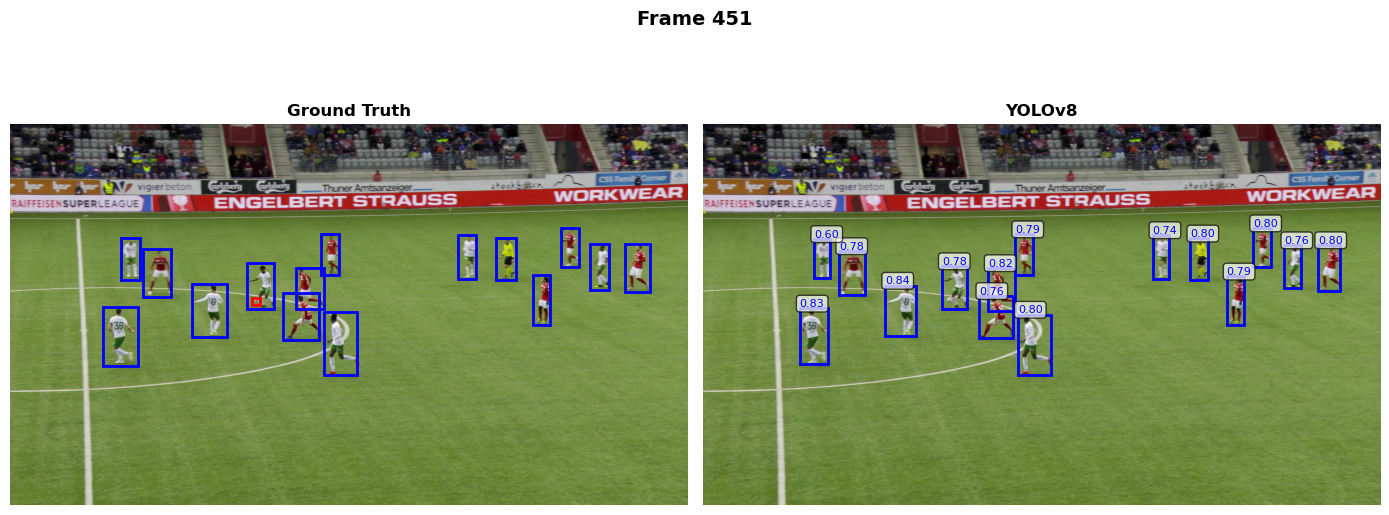

Frame 451:
  GT: 16 objects (15 players, 1 balls)
  YOLO: 15 detections (15 players, 0 balls)


✓ Visualization complete!


In [7]:
# Select frames to visualize (every 50 frames for variety)
all_frames = sorted(gt_per_frame.keys())
selected_frames = all_frames[::50][:10]  # Up to 10 frames

print(f"Visualizing {len(selected_frames)} frames: {selected_frames}")
print("\nGenerating predictions and visualizations...")
print("This may take a few minutes depending on hardware.\n")

for frame_id in selected_frames:
    # Load image
    img_path = img_dir / f"{frame_id:06d}.jpg"
    if not img_path.exists():
        print(f"⚠ Frame {frame_id} not found, skipping")
        continue
    
    img_pil = Image.open(img_path).convert('RGB')
    img_np = np.array(img_pil)
    
    # Get ground truth
    gt_dets = gt_per_frame.get(frame_id, [])
    
    # Get YOLO predictions
    if yolo_available:
        yolo_dets = predict_yolo(yolo_model, img_path, conf_thresh=0.25)
    else:
        yolo_dets = []
    
    # Draw comparison
    fig = draw_comparison(img_np, gt_dets, yolo_dets, frame_id)
    plt.show()
    
    # Print detection counts
    print(f"Frame {frame_id}:")
    print(f"  GT: {len(gt_dets)} objects ({sum(1 for d in gt_dets if d['class']==0)} players, {sum(1 for d in gt_dets if d['class']==1)} balls)")
    print(f"  YOLO: {len(yolo_dets)} detections ({sum(1 for d in yolo_dets if d['class']==0)} players, {sum(1 for d in yolo_dets if d['class']==1)} balls)")
    print()

print("\n✓ Visualization complete!")

## Video Comparison

Generate and display a side-by-side video comparison of Ground Truth vs YOLOv8 predictions.

In [8]:
import cv2
import time

def play_comparison_video(max_frames=300, fps=25):
    """
    Play a side-by-side video comparison of GT and YOLO predictions in a separate window.
    Press ESC or 'q' to stop playback.
    
    Args:
        max_frames: Maximum number of frames to process (default 300 = 12 seconds at 25fps)
        fps: Frames per second for playback
    """
    if not yolo_available:
        print("✗ YOLO model not available, cannot generate video")
        return
    
    # Get all frames
    all_frame_ids = sorted(gt_per_frame.keys())[:max_frames]
    
    print(f"Playing side-by-side comparison for {len(all_frame_ids)} frames")
    print(f"Duration: {len(all_frame_ids)/fps:.1f} seconds at {fps} fps")
    print("Press ESC or 'q' to stop playback\n")
    
    window_name = "GT vs YOLOv8 Comparison"
    frame_period = 1.0 / fps
    window_created = False
    
    try:
        for idx, frame_id in enumerate(all_frame_ids):
            t0 = time.perf_counter()
            
            if (idx + 1) % 50 == 0:
                print(f"  Playing frame {idx + 1}/{len(all_frame_ids)}...")
            
            img_path = img_dir / f"{frame_id:06d}.jpg"
            if not img_path.exists():
                continue
            
            # Load image
            img_cv = cv2.imread(str(img_path))
            if img_cv is None:
                continue
            
            # Create two copies for GT and YOLO
            img_gt = img_cv.copy()
            img_yolo = img_cv.copy()
            
            # Draw ground truth boxes
            gt_dets = gt_per_frame.get(frame_id, [])
            for det in gt_dets:
                x, y, w, h = det['bbox']
                color = (0, 0, 255) if det['class'] == 1 else (255, 0, 0)  # BGR: red for ball, blue for player
                cv2.rectangle(img_gt, (int(x), int(y)), (int(x+w), int(y+h)), color, 2)
            
            # Get and draw YOLO predictions
            yolo_dets = predict_yolo(yolo_model, img_path, conf_thresh=0.25)
            
            for det in yolo_dets:
                x, y, w, h = det['bbox']
                color = (0, 0, 255) if det['class'] == 1 else (255, 0, 0)  # BGR: red for ball, blue for player
                cv2.rectangle(img_yolo, (int(x), int(y)), (int(x+w), int(y+h)), color, 2)
                
                # Add confidence score
                if 'score' in det:
                    cv2.putText(img_yolo, f"{det['score']:.2f}", (int(x), int(y)-5),
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
            
            # Add labels
            cv2.putText(img_gt, 'Ground Truth', (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 255, 255), 2)
            cv2.putText(img_yolo, 'YOLOv8', (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 255, 255), 2)
            
            # Combine side by side
            combined = np.hstack([img_gt, img_yolo])
            
            # Create window when first frame is ready
            if not window_created:
                cv2.namedWindow(window_name, cv2.WINDOW_AUTOSIZE)
                window_created = True
            
            # Display frame
            cv2.imshow(window_name, combined)
            
            # Adaptive delay to maintain target FPS
            elapsed = time.perf_counter() - t0
            remaining = frame_period - elapsed
            delay_ms = 1 if remaining <= 0 else int(remaining * 1000)
            
            # Check for key press
            key = cv2.waitKey(delay_ms) & 0xFF
            if key in (27, ord('q')):  # ESC or q
                print("\n⏹ Playback stopped by user")
                break
        
        print("\n✓ Playback complete!")
        
    finally:
        cv2.destroyWindow(window_name)
        cv2.waitKey(1)  # Let macOS process the close

# Play the comparison video
play_comparison_video(max_frames=300, fps=25)

Playing side-by-side comparison for 300 frames
Duration: 12.0 seconds at 25 fps
Press ESC or 'q' to stop playback

  Playing frame 50/300...
  Playing frame 50/300...
  Playing frame 100/300...
  Playing frame 100/300...
  Playing frame 150/300...
  Playing frame 150/300...
  Playing frame 200/300...
  Playing frame 200/300...
  Playing frame 250/300...
  Playing frame 250/300...
  Playing frame 300/300...

✓ Playback complete!
  Playing frame 300/300...

✓ Playback complete!


---

## Summary

This demo shows the visual detection quality of YOLOv8 compared to ground truth annotations.

**Key Observations:**
- **YOLOv8** generally produces high-quality detections with good confidence scores
- **Ball detection** (red boxes) is challenging due to small object size
- **Player detection** (blue boxes) is very consistent and accurate

**Quantitative Metrics** (see `model_evaluation.ipynb`):
- **YOLOv8**: AP 33.9%, AP50 59.9%

YOLOv8 significantly outperformed Faster R-CNN (AP 8.4%) in our experiments, making it the clear choice for this soccer player and ball detection task.